# Conception du modèle — Classification Nutri-Score à partir des ingrédients

Ce notebook retrace toutes les étapes de conception du modèle déployé dans le backend Flask ([`app.py`](app.py)) :

- **Objectif** : prédire le grade **Nutri-Score** (`A`–`E`, ou `NOT-APPLICABLE`) d'un produit à partir du **texte de ses ingrédients**, tel qu'extrait par OCR de l'étiquette dans l'application mobile.
- **Artefacts produits** : `vectorizer_model.pkl` (vectoriseur TF-IDF) et `main_model.pkl` (régression logistique), chargés au démarrage par `app.py`.

**Pipeline final** :

```
texte ingrédients (OCR) → clean_text (identique à utils.py) → TfidfVectorizer(max_features=3000) → LogisticRegression(max_iter=1000)
```

> Ré-exécuter ce notebook régénère les deux fichiers `.pkl` à partir des données actuelles de `foods_health_scores_allergens.csv`.

## 1. Imports et configuration

In [1]:
import re

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

## 2. Chargement et exploration des données

Le jeu de données `foods_health_scores_allergens.csv` (extrait d'Open Food Facts) contient ~5 000 produits
avec leurs ingrédients, leur grade Nutri-Score et des informations nutritionnelles.
Seules deux colonnes servent à ce modèle : `ingredients` (entrée) et `nutriscore_grade` (cible).

In [2]:
df = pd.read_csv("foods_health_scores_allergens.csv")

print("Dimensions :", df.shape)
df[["product_name", "ingredients", "nutriscore_grade"]].head()

Dimensions : (4997, 24)


,product_name,ingredients,nutriscore_grade
0,Sidi Ali,OBD1 999 999 1112606 266963207 mb,A
1,Perly,"milk cream, cream, sugar, banana, bacteria",UNKNOWN
2,Sidi Ali,"Sodium, Calcium, Magnésium, Potassium, Bicarbo...",A
3,Eau minérale naturelle,100% mineral water,A
4,اكوافينا,ouverture et avant le : Voir bouteille. après ...,A


nutriscore_grade
C                 1072
E                  995
D                  899
A                  833
B                  648
UNKNOWN            401
NOT-APPLICABLE     135
NaN                 14
Name: count, dtype: int64


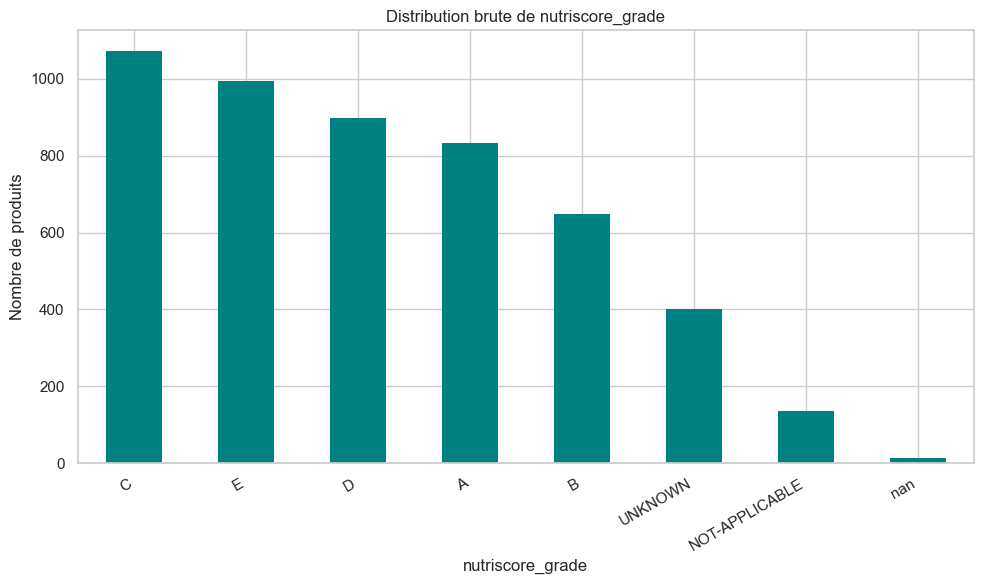

In [3]:
# Distribution brute de la cible (avant filtrage)
counts = df["nutriscore_grade"].value_counts(dropna=False)
print(counts)

ax = counts.plot(kind="bar", color="teal", edgecolor="none")
ax.set_title("Distribution brute de nutriscore_grade")
ax.set_ylabel("Nombre de produits")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Constitution du jeu d'entraînement

Choix des classes conservées :

- **`A`–`E`** : les grades Nutri-Score réels — c'est ce que l'application doit prédire.
- **`NOT-APPLICABLE`** : produits pour lesquels le Nutri-Score ne s'applique pas (eaux, cafés, etc.).
  Conserver cette classe permet au modèle de la prédire au lieu de forcer un grade erroné sur ce type d'étiquette.
- **`UNKNOWN` et valeurs manquantes : exclus** — un grade inconnu n'est pas une étiquette exploitable pour
  l'apprentissage supervisé (ce n'est pas une catégorie de produit, juste une absence d'information).

On exclut aussi les lignes sans texte d'ingrédients (l'entrée du modèle).

In [4]:
CLASSES = ["A", "B", "C", "D", "E", "NOT-APPLICABLE"]

data = df[df["nutriscore_grade"].isin(CLASSES) & df["ingredients"].notna()].copy()

print("Taille du jeu retenu :", len(data))
print()
print(data["nutriscore_grade"].value_counts())

Taille du jeu retenu : 4502

nutriscore_grade
C                 1064
E                  969
D                  889
A                  817
B                  634
NOT-APPLICABLE     129
Name: count, dtype: int64


## 4. Nettoyage du texte

Le nettoyage doit être **strictement identique à `clean_text` de `utils.py`**, appliqué au texte OCR
au moment de l'inférence : minuscules, suppression de tout caractère non alphabétique
(chiffres, ponctuation, symboles issus du bruit OCR), normalisation des espaces.

Cette cohérence entraînement/inférence est indispensable : le vectoriseur doit voir en production
des tokens de la même forme que ceux vus à l'entraînement.

In [5]:
def clean_text(text):
    """Copie exacte de utils.clean_text (backend/utils.py)."""
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z ]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


data["text_clean"] = data["ingredients"].map(clean_text)

# Avant / après sur un exemple représentatif (étiquette riche en ingrédients)
example = data[data["ingredients"].str.len() > 80].iloc[0]
print("AVANT :", example["ingredients"][:200])
print()
print("APRÈS :", example["text_clean"][:200])

AVANT : ouverture et avant le : Voir bouteille. après مياه مصفاة بتقنية اكوافينا هايدرو - 7 Eau purifiée par la technique Aquafina HydRO-7

APRÈS : ouverture et avant le voir bouteille apr s eau purifi e par la technique aquafina hydro


## 5. Découpage entraînement / test

Découpage stratifié 80 / 20 (graine fixe) pour évaluer honnêtement le modèle sur des produits jamais vus,
en conservant les proportions de chaque grade.

In [6]:
X = data["text_clean"]
y = data["nutriscore_grade"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED,
)

print("Entraînement :", len(X_train), "— Test :", len(X_test))
print()
print(y_train.value_counts(normalize=True).round(3))

Entraînement : 3601 — Test : 901

nutriscore_grade
C                 0.236
E                 0.215
D                 0.197
A                 0.182
B                 0.141
NOT-APPLICABLE    0.029
Name: proportion, dtype: float64


## 6. Comparaison de classifieurs

Tous les candidats utilisent la **même vectorisation TF-IDF** (`max_features=3000`) pour une comparaison
équitable : seule la famille de classifieur change. `max_features=3000` limite le vocabulaire aux 3 000
termes les plus fréquents — un bon compromis entre pouvoir prédictif et légèreté de l'artefact
(le backend tourne sur une petite instance CPU).

In [7]:
def make_features(X_train, X_test, max_features=3000):
    vec = TfidfVectorizer(max_features=max_features)
    return vec, vec.fit_transform(X_train), vec.transform(X_test)


vec_cmp, Xtr_cmp, Xte_cmp = make_features(X_train, X_test)

candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "MultinomialNB": MultinomialNB(),
    "LinearSVC": LinearSVC(),
    "SGDClassifier (log-loss)": SGDClassifier(loss="log_loss", max_iter=2000, random_state=RANDOM_SEED),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1),
}

rows = []
for name, model in candidates.items():
    model.fit(Xtr_cmp, y_train)
    pred = model.predict(Xte_cmp)
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "predict_proba": hasattr(model, "predict_proba"),
    })

results = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
results

,model,accuracy,balanced_accuracy,macro_f1,predict_proba
0,RandomForest,0.580466,0.531640,0.550303,True
1,LinearSVC,0.549390,0.518806,0.527562,False
2,SGDClassifier (log-loss),0.547170,0.484485,0.498966,True
3,LogisticRegression,0.533851,0.459372,0.466879,True
4,MultinomialNB,0.477248,0.384858,0.375829,True


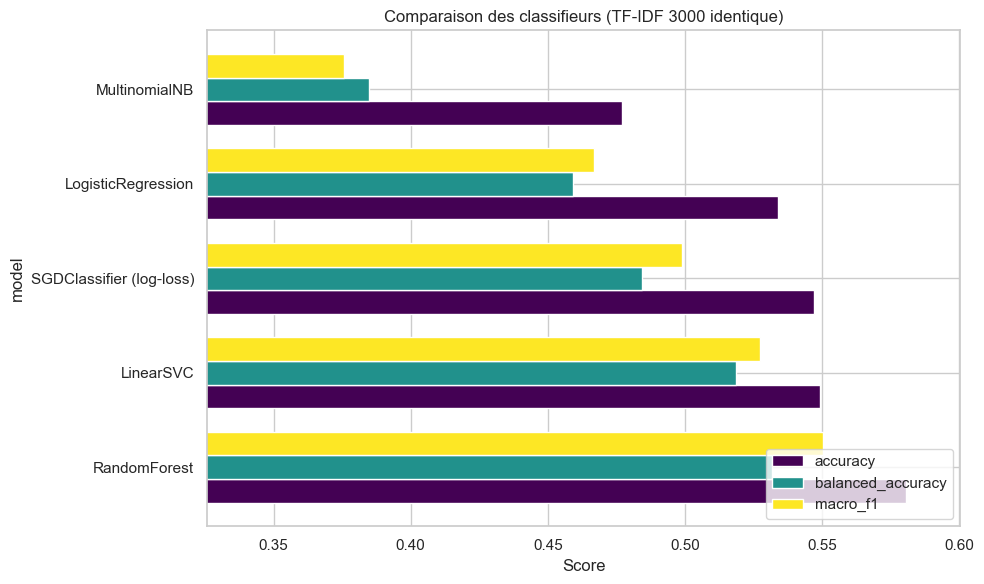

In [8]:
m = results.set_index("model")[["accuracy", "balanced_accuracy", "macro_f1"]]
ax = m.plot(kind="barh", width=0.75, colormap="viridis")
ax.set_xlim(max(0.0, m.min().min() - 0.05), m.max().max() + 0.02)
ax.set_title("Comparaison des classifieurs (TF-IDF 3000 identique)")
ax.set_xlabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Choix du modèle : régression logistique

RandomForest obtient le meilleur macro-F1 sur ce split, mais c'est la **régression logistique**
qui est retenue pour le déploiement — le choix est dicté par les contraintes de production autant
que par les scores :

1. **Probabilités calibrées** : l'API renvoie un score de confiance
   (`model.predict_proba(vec).max()` dans `app.py`). LinearSVC n'expose pas `predict_proba`, ce qui l'élimine.
2. **Taille de l'artefact** : ~150 Ko, contre **~76 Mo** pour une forêt de 200 arbres sur ces mêmes
   features — décisif pour un hébergement gratuit à mémoire limitée (Render, cf. `render.yaml`),
   où le modèle est chargé en RAM au démarrage et versionné dans le dépôt Git.
3. **Latence** : inférence en millisecondes sur CPU, adaptée à une API synchrone.
4. **Interprétabilité** : les coefficients par classe restent inspectables.

`max_iter=1000` garantit la convergence de l'optimiseur sur ces données (le défaut de 100 itérations
déclenche un avertissement de non-convergence).

## 8. Évaluation détaillée du modèle retenu

In [9]:
vectorizer_eval = TfidfVectorizer(max_features=3000)
X_train_vec = vectorizer_eval.fit_transform(X_train)
X_test_vec = vectorizer_eval.transform(X_test)

model_eval = LogisticRegression(max_iter=1000)
model_eval.fit(X_train_vec, y_train)

y_pred = model_eval.predict(X_test_vec)

print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

             A       0.55      0.70      0.62       163
             B       0.59      0.26      0.36       127
             C       0.47      0.61      0.53       213
             D       0.47      0.42      0.44       178
             E       0.64      0.65      0.64       194
NOT-APPLICABLE       1.00      0.12      0.21        26

      accuracy                           0.53       901
     macro avg       0.62      0.46      0.47       901
  weighted avg       0.55      0.53      0.52       901



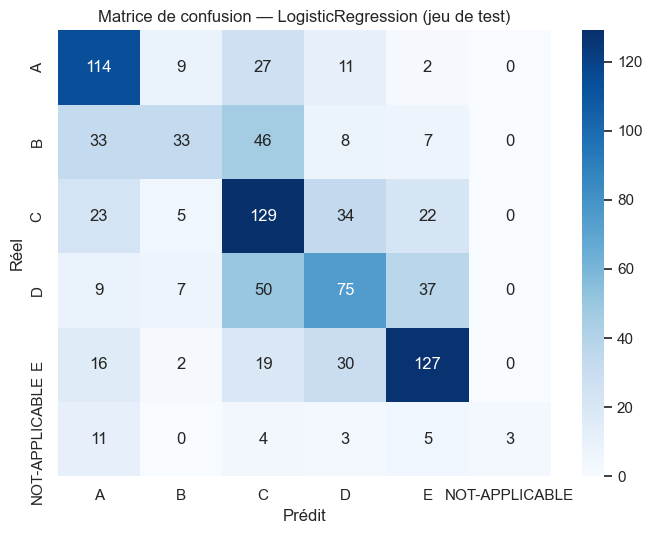

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Matrice de confusion — LogisticRegression (jeu de test)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

Les erreurs se concentrent entre **grades adjacents** (B↔C, C↔D) — attendu, le Nutri-Score étant une
échelle quasi ordinale : confondre B et C est bien moins grave que confondre A et E.
La classe `NOT-APPLICABLE` est bien séparée des grades réels.

## 9. Ré-entraînement final et simulation de l'inférence

Le modèle validé, on ré-entraîne le vectoriseur et le classifieur sur **100 % des données retenues**
(pratique standard : le split ne servait qu'à l'évaluation) — ce sont ces objets qui sont déployés.

On simule ensuite exactement le chemin d'inférence de `app.py` :
`clean_text` → `vectorizer.transform` → garde-fou `nnz < 5` → `predict` + `predict_proba`.

In [11]:
vectorizer = TfidfVectorizer(max_features=3000)
X_all_vec = vectorizer.fit_transform(X)

model = LogisticRegression(max_iter=1000)
model.fit(X_all_vec, y)

print("Vocabulaire :", len(vectorizer.vocabulary_), "termes")
print("Classes du modèle :", model.classes_)

Vocabulaire : 3000 termes
Classes du modèle : ['A' 'B' 'C' 'D' 'E' 'NOT-APPLICABLE']


In [12]:
# Simulation du flux d'inférence de app.py sur un texte type d'étiquette OCR
sample_ocr = (
    "INGREDIENTS: Sucre, huile de palme, NOISETTES 13%, cacao maigre 7,4%, "
    "LAIT écrémé en poudre 6,6%, lécithines [SOJA], vanilline."
)

clean = clean_text(sample_ocr)          # 1. nettoyage (utils.clean_text)
vec = vectorizer.transform([clean])     # 2. vectorisation

if vec.nnz < 5:                         # 3. garde-fou de app.py
    print("Rejeté : pas assez de données alimentaires détectées")
else:
    grade = model.predict(vec)[0]       # 4. prédiction
    confidence = float(model.predict_proba(vec).max())
    print("Texte nettoyé :", clean)
    print("Grade prédit  :", grade)
    print("Confiance     :", round(confidence, 2))

Texte nettoyé : ingredients sucre huile de palme noisettes cacao maigre lait cr m en poudre l cithines soja vanilline
Grade prédit  : E
Confiance     : 0.94


## 10. Sauvegarde des artefacts déployés

Le vectoriseur et le modèle sont sauvegardés **séparément** — `app.py` les recharge ainsi :

```python
model = joblib.load("main_model.pkl")
vectorizer = joblib.load("vectorizer_model.pkl")
```

In [13]:
from pathlib import Path

joblib.dump(vectorizer, "vectorizer_model.pkl")
joblib.dump(model, "main_model.pkl")

for f in ["vectorizer_model.pkl", "main_model.pkl"]:
    print(f"{f} : {Path(f).stat().st_size / 1024:.0f} Ko")

vectorizer_model.pkl : 109 Ko
main_model.pkl : 142 Ko


## Résumé

| Étape | Choix | Justification |
|---|---|---|
| Données | `foods_health_scores_allergens.csv` (~5 000 produits) | Extrait Open Food Facts avec ingrédients + Nutri-Score |
| Cible | `A`–`E` + `NOT-APPLICABLE` (6 classes) | `UNKNOWN`/NaN exclus (absence d'étiquette) |
| Nettoyage | `clean_text` identique à `utils.py` | Cohérence entraînement / inférence sur texte OCR |
| Vectorisation | `TfidfVectorizer(max_features=3000)` | Compromis performance / taille de l'artefact |
| Classifieur | `LogisticRegression(max_iter=1000)` | `predict_proba` requis par l'API + artefact ~150 Ko (vs ~76 Mo pour RandomForest) |
| Évaluation | Split stratifié 80/20, macro-F1 + matrice de confusion | Erreurs concentrées sur grades adjacents |
| Déploiement | Ré-entraînement sur 100 % des données, sauvegarde `joblib` | `main_model.pkl` + `vectorizer_model.pkl` chargés par `app.py` |